In [2]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[1])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import TotalVariationRecon, L1WaveletRecon
from scipy.io import savemat
import twixtools
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.signal import butter,filtfilt


## My files
from ksp_plot_helpers import plot_ksp_data_multichannel, find_and_plot_acquired_region
from raw_data_utils import get_kspace_data, get_TR
from resp_signal_functions import resp_signal_all_slices, resp_signal_single_slice, resp_signal_center_sample_single_slice
from resp_signal_plot_functions import *
import gating_functions
from pca_helper import pca_resp_signal
from save_data_helpers import *

### Load k-space with full # of readouts

Software version: VD/VE (!?)

Scan  0


100%|██████████| 15.9G/15.9G [00:13<00:00, 1.29GB/s]


Full number of partitions = 72
ksp_data.shape = (15, 58, 2002, 256)
Average value, slices vs samples per gate = 3.577272582333535e-05
Average value, readouts vs spokes per gate = 1.9743638404179364e-05
Average value, slices vs center sample per gate = 0.00014247720537241548


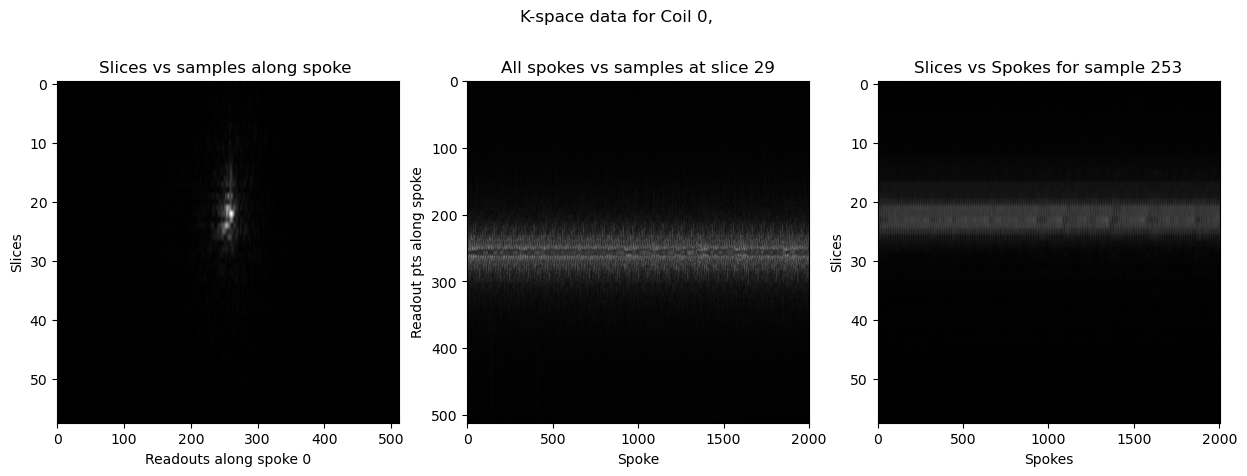

In [3]:
data_file_pt2 = '/data/lilianae/NaF_Patient2/anon_meas_MID00082_FID64646_Tho_fl3d_star_vibe_991_nav_tj_2000sp_AllCoils_SOS_2.dat'
multi_twix, mapped, _ = get_kspace_data(data_file_pt2)

ksp_512 = read_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/ksp_from_mdb_512_samples.pkl')
ksp_512 = np.transpose(ksp_512, (2, 0, 1, 3))
fig, axs = plot_ksp_data_multichannel(ksp_data=ksp_512, coil_idx=0, center_sample=253)

In [4]:
TR = get_TR(mapped)

TR from data: 0.006 sec


### Use dense gating

In [5]:
start_sample_idx = 250
end_sample_idx = 260

In [6]:

print(f"\nUse center sample + center slice for signal: ")
print("="*60)

raw_signal_all_slices, filt_signal_all_slices= resp_signal_all_slices(ksp_512, 
                                                                        TR=TR,
                                                                        cutoff_hz=[0.2, 0.33], 
                                                                        start_sample_idx=start_sample_idx,
                                                                        end_sample_idx=end_sample_idx,
                                                                        filter_type='bandpass')


Use center sample + center slice for signal: 
Sampling frequency (Hz): 166.667
full timescale goes to 696.69 seconds
filt_signal_all.shape: (15, 116116)
raw_signal_all.shape: (15, 116116)


### Plot raw signal

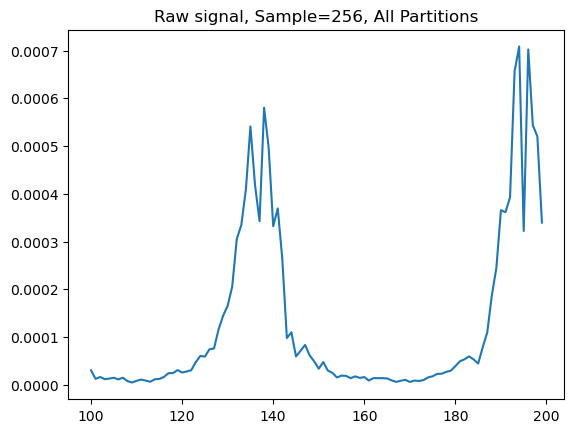

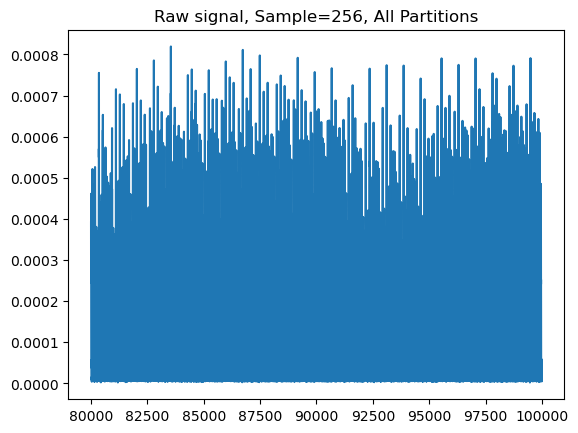

In [24]:
def plot_raw_signal_only(signal, coil_idx, start_idx, end_idx, title=""):
    fig, axs = plt.subplots()
    x_axis = np.arange(start_idx, end_idx)
    axs.plot(x_axis, signal[coil_idx][start_idx:end_idx])
    axs.set_title(f'{title}')
    plt.show()

    
start_idx = 100
end_idx=200
plot_raw_signal_only(raw_signal_all_slices, coil_idx=8,
                     start_idx=start_idx, end_idx=end_idx, title="Raw signal, Sample=256, All Partitions")

start_idx = 80000
end_idx=100000
plot_raw_signal_only(raw_signal_all_slices, coil_idx=8,
                     start_idx=start_idx, end_idx=end_idx, title="Raw signal, Sample=256, All Partitions")


### Plot frequency spectrum

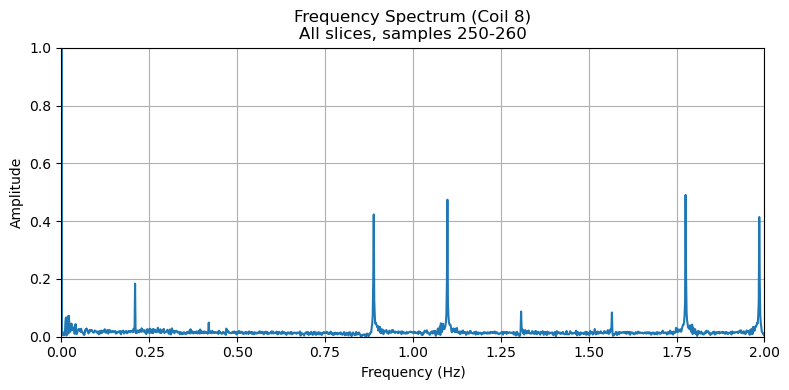

In [8]:
def plot_freq_spectrum(signal_coils, coil_idx, TR, fmax=2, amp_limit=None, title_info=""):
    """
    Plot the frequency spectrum (magnitude of FFT) for a given coil signal.

    Parameters
    ----------
    signal_coils : array-like
        Array of signals from different coils, shape (num_coils, num_samples)
    coil_idx : int
        Index of the coil to analyze
    TR : float
        Sampling interval (s)
    fmax : float, optional
        Maximum frequency (Hz) to display (default 2 Hz)
    amp_limit: float, optional
        Set y-axis limit to better zoom in
    title_info : str, optional
        Title info for plot
    """
    fs = 1 / TR
    signal = signal_coils[coil_idx]
    n = len(signal)

    # Compute FFT and frequencies
    fft_result = np.fft.fft(signal)
    freq = np.fft.fftfreq(n, d=TR)

    # Use only positive frequencies
    pos_mask = freq >= 0
    freq = freq[pos_mask]
    fft_result = np.abs(fft_result[pos_mask])

    # Plot
    plt.figure(figsize=(8, 4))
    plt.plot(freq, fft_result)
    plt.xlim(0, fmax)
    if amp_limit is not None:
            plt.ylim(0, amp_limit)
    plt.title(f'Frequency Spectrum (Coil {coil_idx})' f'\n{title_info}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

coil_idx = 8
title = "All slices, samples 250-260"
plot_freq_spectrum(raw_signal_all_slices, coil_idx=coil_idx, TR=TR, fmax=2, 
                   amp_limit=1, title_info=f'{title}')

### Plot raw and filtered signal

In [27]:
def plot_raw_and_filtered_signal2(raw_signal_all, filt_signal_all, 
                                 coil_indices, TR, samples_to_discard=0, time_axis_seconds=None, title_info=""):
    
    '''
    Plot raw and filtered respiratory signal 

    Inputs
    --------------------------
    raw_signal_all : ndarray
        Raw resp signal, shape (num_channels, num_points)

    filt_signal_all: ndarray
        Filtered signal, shape (num_channels, num_points)

    coil_indices: list
        Coil indices to view

    title_info : str
        Info for suptitle
    Outputs
    ----------------------------
    None
    
    '''
    if time_axis_seconds is None:
        time_axis_seconds = np.arange(len(raw_signal_all[0])) * TR

    for coil in coil_indices:
        raw_respiratory_signal = raw_signal_all[coil, :]  # First coil only
        filt_respiratory_signal = filt_signal_all[coil, : ]


        # Create time axis with 1-second major ticks
        fig, (ax1, ax2) = plt.subplots(1,2, figsize=(20, 8))


        # Plot 1: Raw respiratory signal
        ax1.plot(time_axis_seconds[samples_to_discard:], raw_respiratory_signal[samples_to_discard:], 'b-', linewidth=0.5, alpha=0.7)
        ax1.set_xlabel('Time (seconds)')
        ax1.set_ylabel('Raw Signal Amplitude')
        ax1.set_title(f'Raw Respiratory Signal (Coil {coil})')
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(20, 100)  # First 60 seconds
        # Set major ticks every 1 second
        ax1.set_xticks(np.arange(20, 100, 10))
        ax1.set_xticklabels(np.arange(20, 100, 10))

        # Plot 2: Filtered respiratory signal  
        ax2.plot(time_axis_seconds[samples_to_discard:], filt_respiratory_signal[samples_to_discard:], 'r-', linewidth=1.0)
        ax2.set_xlabel('Time (seconds)')
        ax2.set_ylabel('Filtered Signal Amplitude')
        ax2.set_title(f'Filtered Respiratory Signal (Coil {coil})')
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(20, 100)  # First 60 seconds
        # Set major ticks every 1 second
        ax2.set_xticks(np.arange(20, 100, 10))
        ax2.set_xticklabels(np.arange(20, 100, 10))

        fig.suptitle(f"{title_info}", y=1.02, fontsize=20)
        plt.tight_layout()
        plt.show()

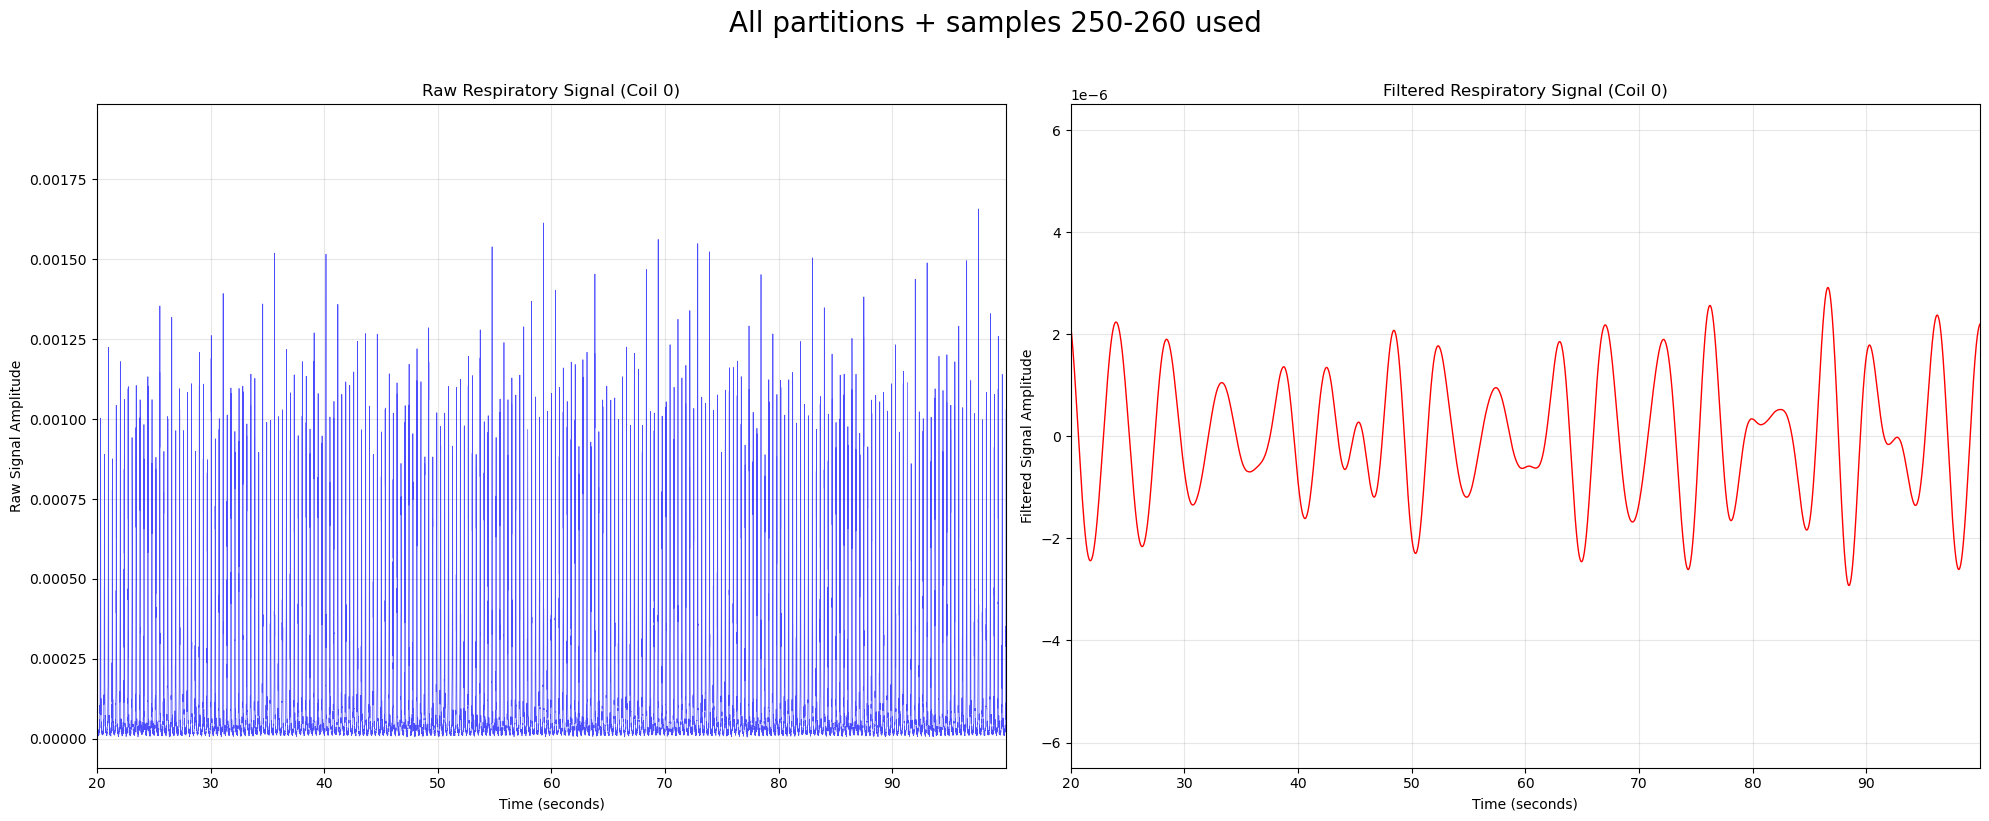

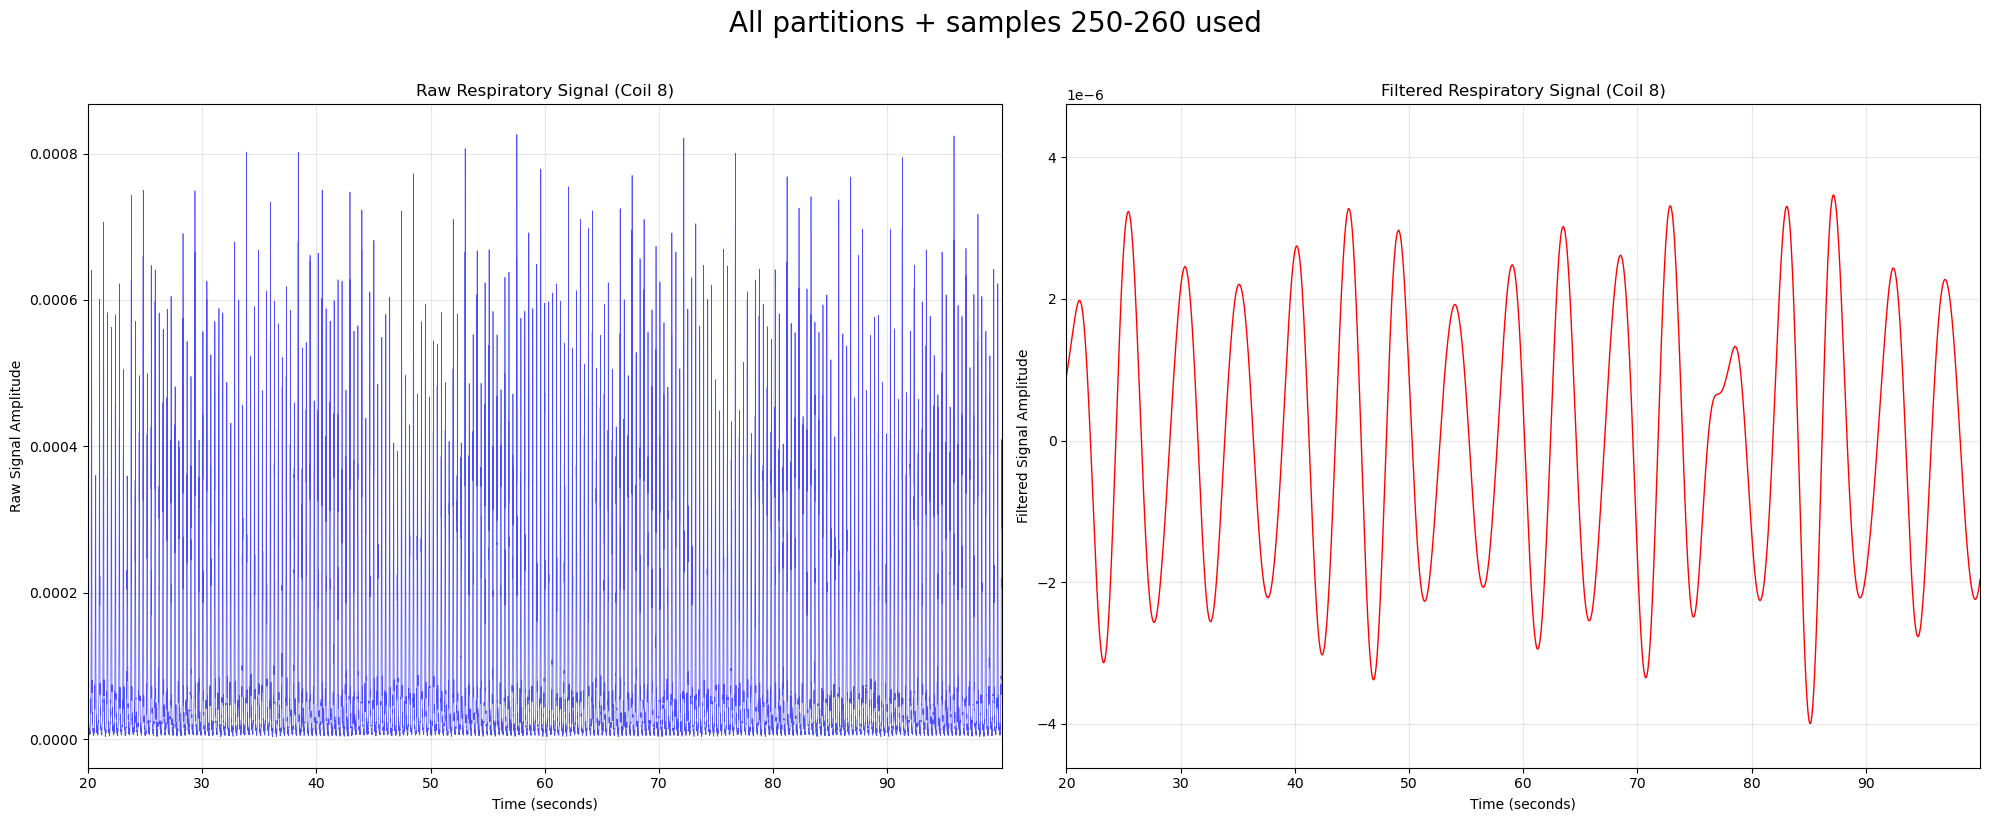

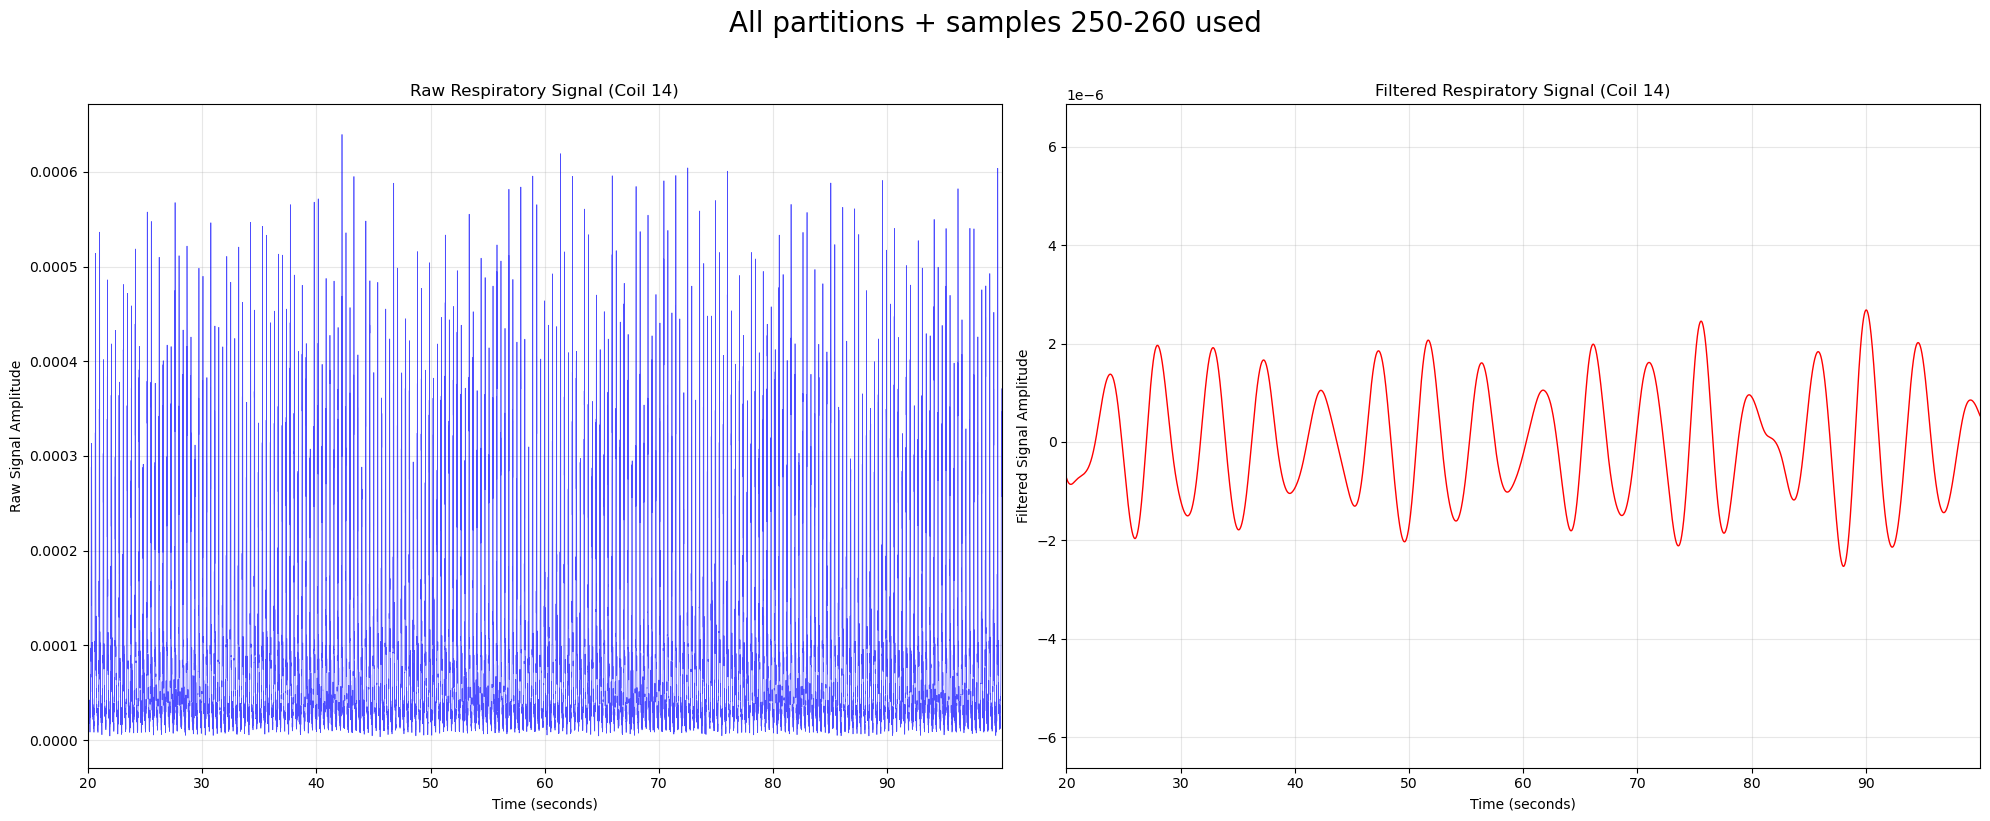

In [29]:
coil_indices = [0, 8, 14]

plot_raw_and_filtered_signal2(raw_signal_all_slices, filt_signal_all_slices, coil_indices, TR, samples_to_discard=3000, title_info="All partitions + samples 250-260 used")

### PCA

In [10]:
n_components = 3
resp_center_pca = pca_resp_signal(filt_signal_all_slices, n_components=n_components)

Final respiratory signal shape: (116116,)
PCA explained variance ratio: 0.927


In [11]:
2000/116116

0.017224155155189637

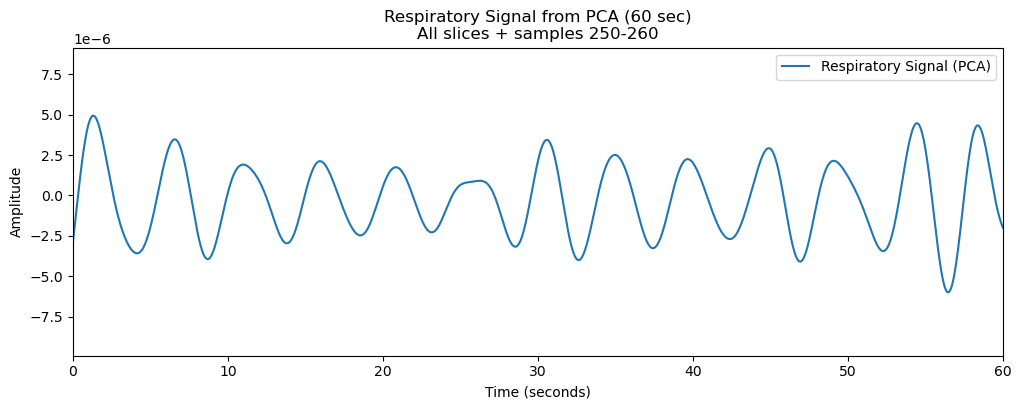

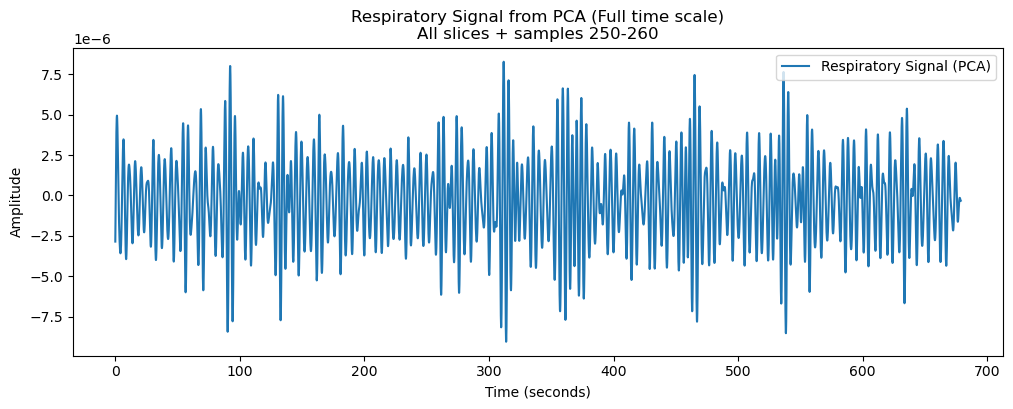

In [36]:
plot_resp_signal(resp_center_pca[3000:], TR=TR, title_info="All slices + samples 250-260")
plot_resp_signal(resp_center_pca[3000:], TR=TR, title_info="All slices + samples 250-260", xlim=False)

### Gating (all partitons)

In [13]:
num_gates = 5
img_shape = (ksp_512.shape[1], ksp_512.shape[3], ksp_512.shape[3])

## Amplitude based
idx, resp_trimmed, data_bins, spoke_bins, index_bins = gating_functions.gate_resp_signal_dense(ksp_512, 
                                                                                               resp_center_pca,
                                                                                               num_gates=num_gates,
                                                                                               img_shape=img_shape,
                                                                                               spokes_to_discard=3000,
                                                                                               gating_method='amplitude')


Gate 1: 22623 spoke groups, 22623 total spokes, , indices = [  0   1   2   3 565 566 567 568 569 570] ...
Gate 2: 22623 spoke groups, 22623 total spokes, , indices = [ 4  5  6  7  8  9 10 11 12 13] ...
Gate 3: 22623 spoke groups, 22623 total spokes, , indices = [34 35 36 37 38 39 40 41 42 43] ...
Gate 4: 22623 spoke groups, 22623 total spokes, , indices = [64 65 66 67 68 69 70 71 72 73] ...
Gate 5: 22624 spoke groups, 22624 total spokes, , indices = [ 95  96  97  98  99 100 101 102 103 104] ...
Gate 1: kspace shape = (15, 22623, 512), coords shape = (22623, 512, 3)
Gate 2: kspace shape = (15, 22623, 512), coords shape = (22623, 512, 3)
Gate 3: kspace shape = (15, 22623, 512), coords shape = (22623, 512, 3)
Gate 4: kspace shape = (15, 22623, 512), coords shape = (22623, 512, 3)
Gate 5: kspace shape = (15, 22624, 512), coords shape = (22624, 512, 3)


Average signal across gates = [-3.998311666221123e-06, -1.929770820407961e-06, -2.688209989741305e-07, 1.2447155061396358e-06, 3.308717429635101e-06]


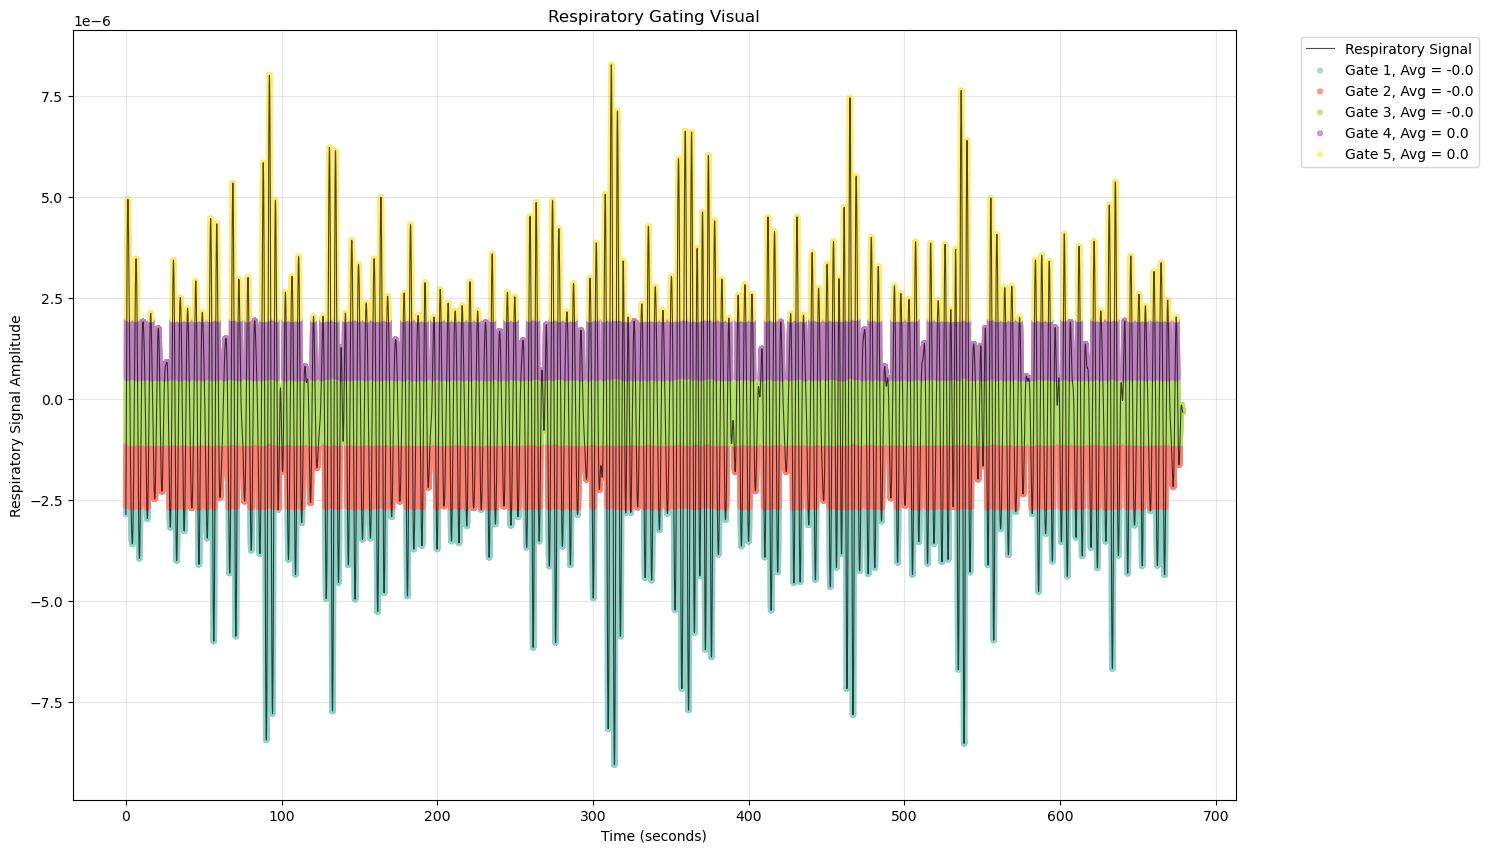

In [14]:
import gating_visuals

gating_visuals.visualize_resp_gating(resp_trimmed, idx, TR=TR, num_gates=5)

Original shape: (15, 22623, 512)
ncoils=15, npts=22623, nsamples=512
Data min: 3.29272248356105e-10
Data max: 0.0014299985487014055
Data mean: 8.83737357071368e-06
Data median: 2.7794274046755163e-06
Data std: 3.392384314793162e-05
Non-zero elements: 11582976 / 11582976


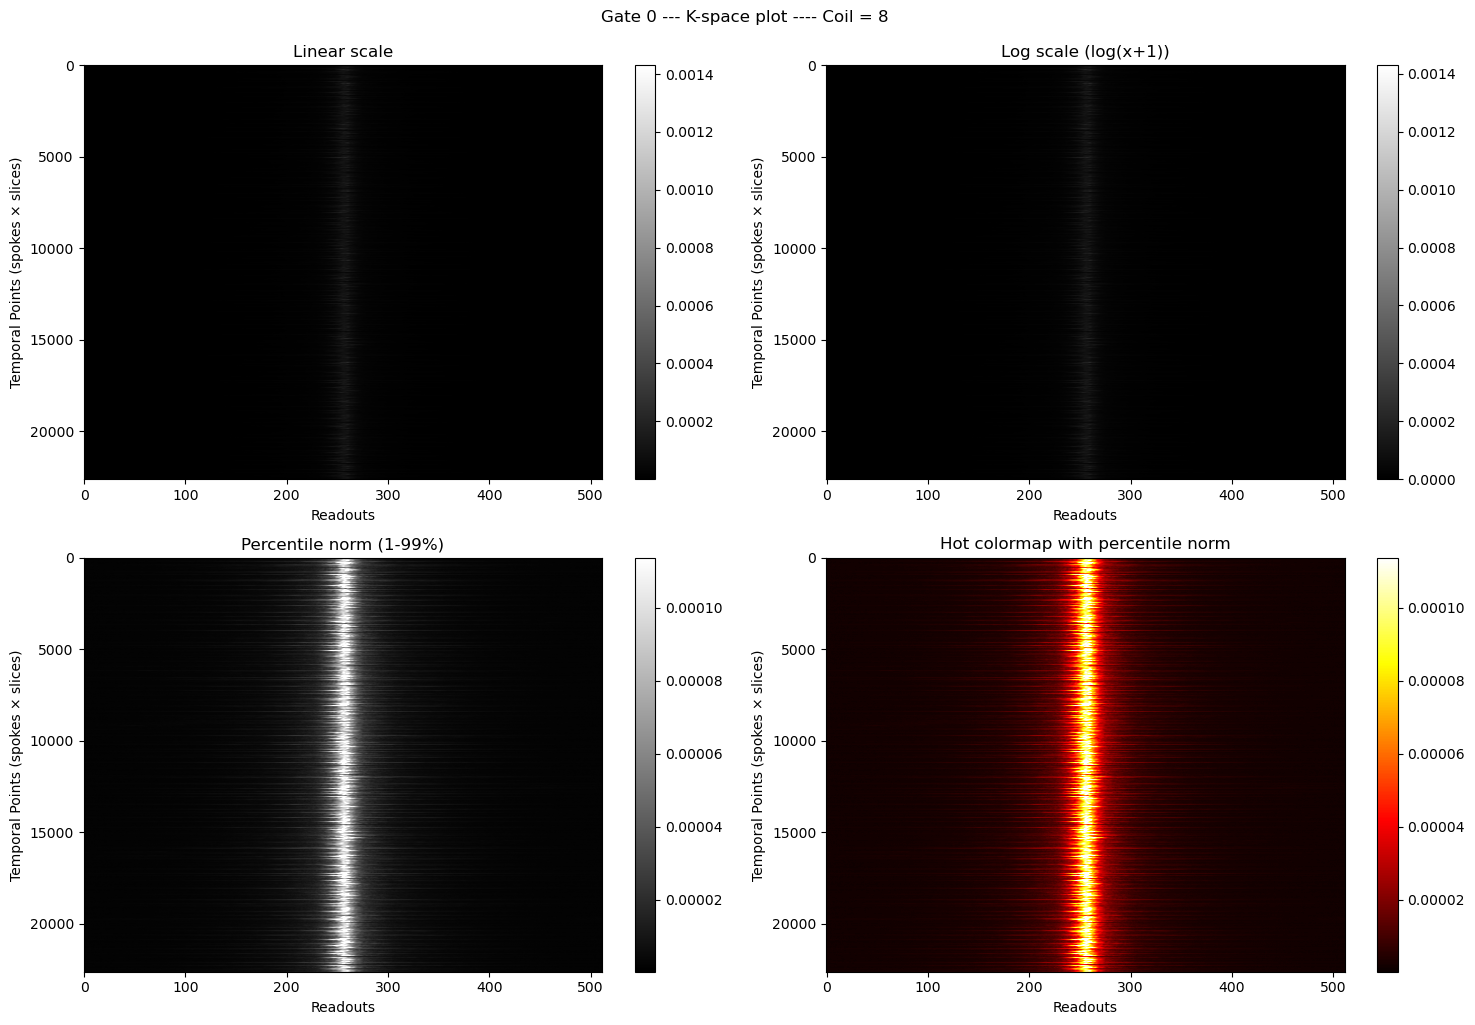

In [35]:
def plot_ksp_data_gate_debug(ksp_data, coil_idx, title=""):
    """Plot ksp data for slices vs (spoke,sample) dimension collapsed"""
    
    print(f"Original shape: {ksp_data.shape}")
    # Original: (ncoils, nspokes * nslices, nsamples)
    
    # ksp_data = ksp_data.transpose(0, 2, 1, 3)
    # print(f"After transpose: {ksp_data.shape}")
    
    ncoils, npts, nsamples = ksp_data.shape
    print(f"ncoils={ncoils}, npts={npts}, nsamples={nsamples}")
    
    # Reshape to collapse spokes and samples into one temporal dimension
    # ksp_data_flat = ksp_data.reshape(ncoils, nslices, -1)
    # print(f"ksp_data_flat.shape = {ksp_data_flat.shape}")
    
    # Extract data for visualization
    plot_data = np.abs(ksp_data[coil_idx, :, :])  # (nslices, temporal_pts)
    
    # DEBUGGING: Check data statistics
    print(f"Data min: {plot_data.min()}")
    print(f"Data max: {plot_data.max()}")
    print(f"Data mean: {plot_data.mean()}")
    print(f"Data median: {np.median(plot_data)}")
    print(f"Data std: {plot_data.std()}")
    print(f"Non-zero elements: {np.count_nonzero(plot_data)} / {plot_data.size}")
    
    # Try different visualizations to see what works
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Linear scale
    im1 = axes[0,0].imshow(plot_data, cmap='gray', aspect='auto')
    axes[0,0].set_title("Linear scale")
    plt.colorbar(im1, ax=axes[0,0])
    
    # Plot 2: Log scale
    im2 = axes[0,1].imshow(np.log(plot_data + 1), cmap='gray', aspect='auto')
    axes[0,1].set_title("Log scale (log(x+1))")
    plt.colorbar(im2, ax=axes[0,1])
    
    # Plot 3: Percentile-based normalization
    vmin, vmax = np.percentile(plot_data, [1, 99])
    im3 = axes[1,0].imshow(plot_data, cmap='gray', aspect='auto', 
                           vmin=vmin, vmax=vmax)
    axes[1,0].set_title(f"Percentile norm (1-99%)")
    plt.colorbar(im3, ax=axes[1,0])
    
    # Plot 4: Hot colormap (better for k-space)
    im4 = axes[1,1].imshow(plot_data, cmap='hot', aspect='auto',
                           vmin=vmin, vmax=vmax)
    axes[1,1].set_title("Hot colormap with percentile norm")
    plt.colorbar(im4, ax=axes[1,1])
    
    for ax in axes.flat:
        ax.set_xlabel("Readouts")
        ax.set_ylabel("Temporal Points (spokes × slices)")
    
    plt.tight_layout()
    fig.suptitle(f'{title}', y =1.02)
    plt.show()


plot_ksp_data_gate_debug(data_bins[0], coil_idx=8, title=f"Gate 0 --- K-space plot ---- Coil = {coil_idx}")

In [ ]:
# save_gate_outputs_pickle('gates_dense_amp_512.pkl', idx, resp_trimmed, data_bins, spoke_bins, index_bins)

File successfully saved as gates_dense_amp_512.pkl
